100%|██████████| 2.64G/2.64G [02:35<00:00, 17.0MB/s]


Training a 101 M model using cuda


/tmp/ipykernel_23/2657699393.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots()


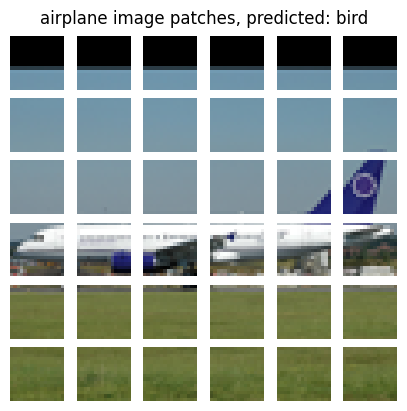

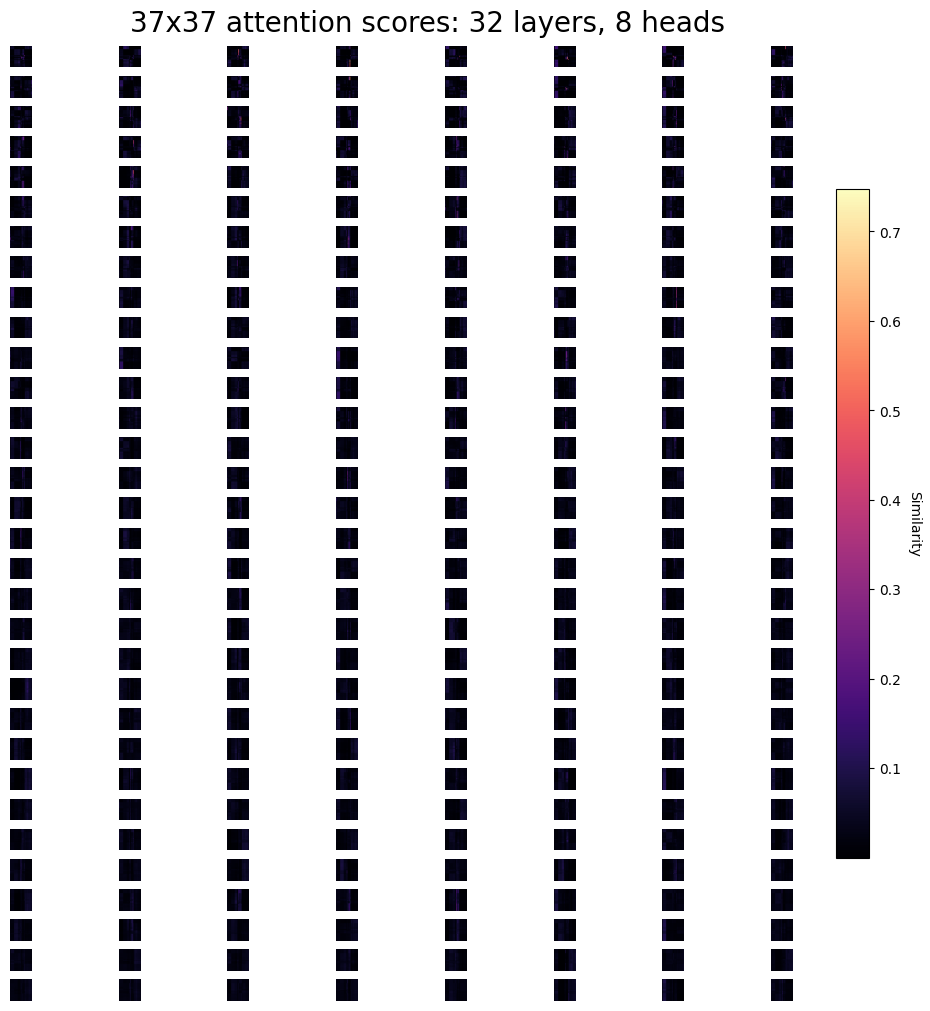

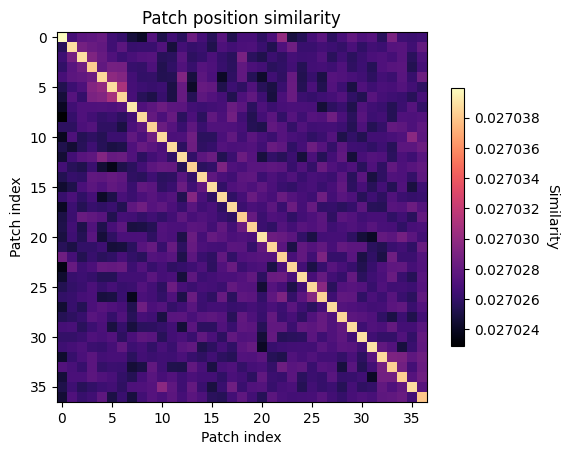

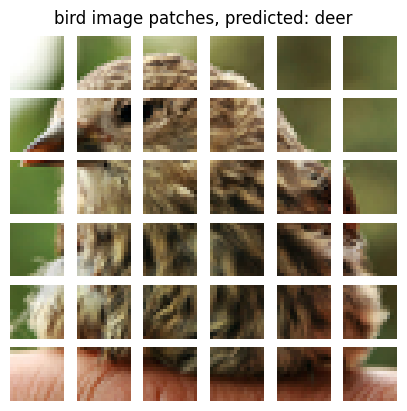

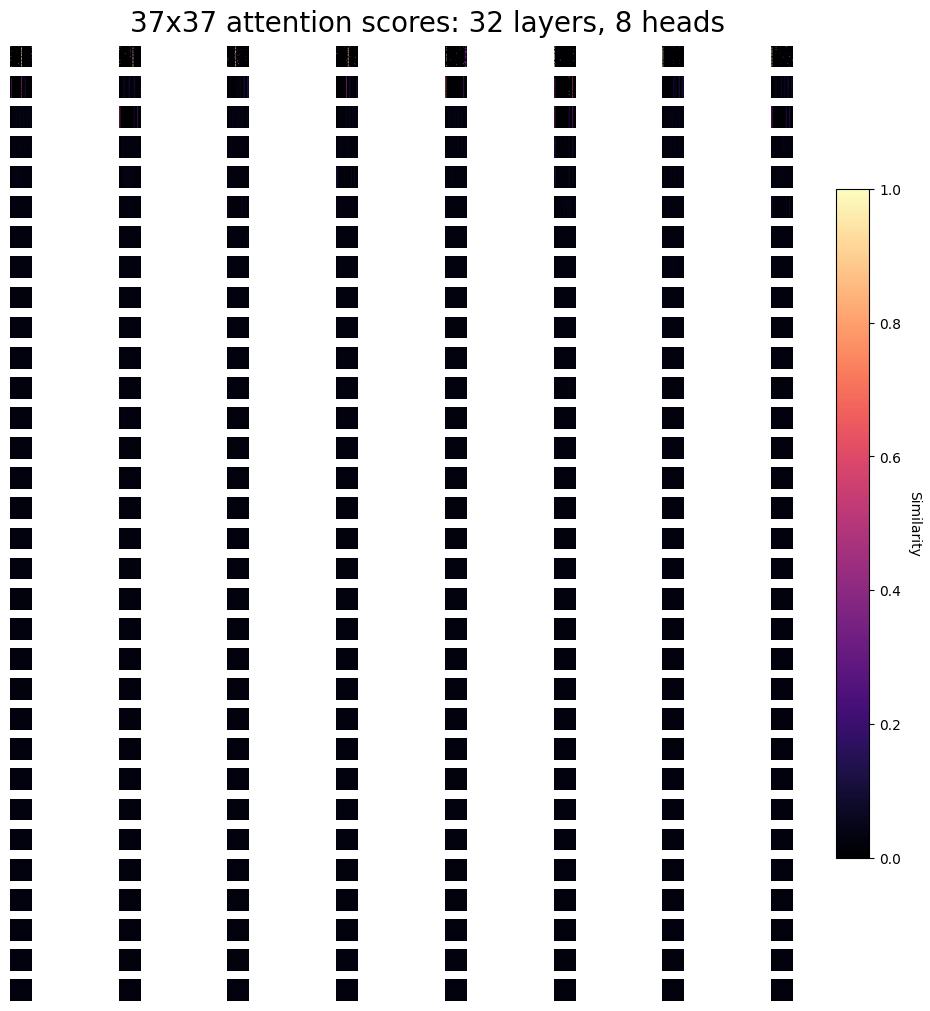

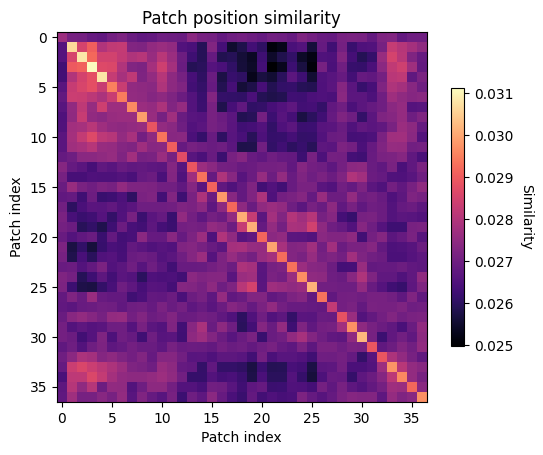

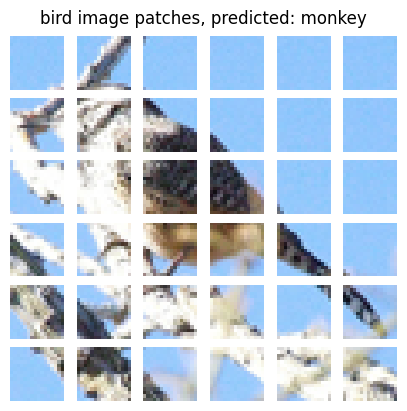

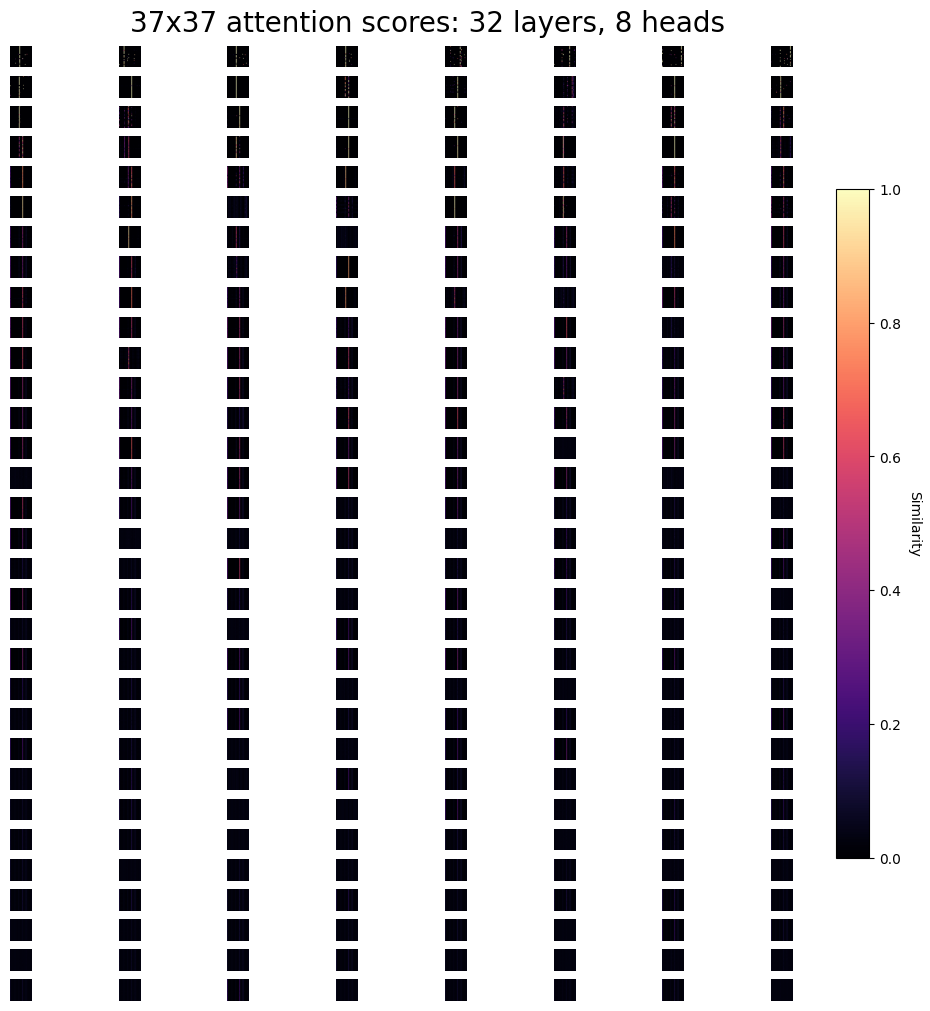

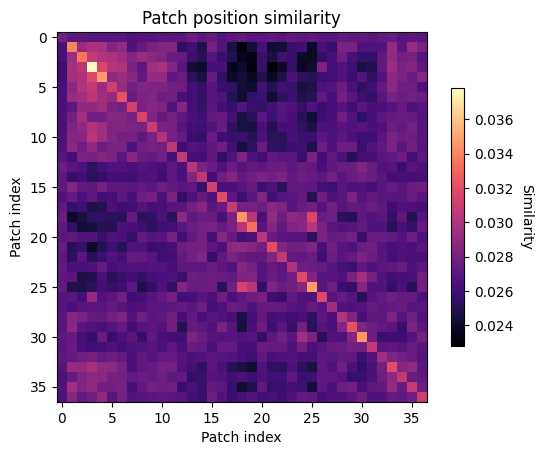

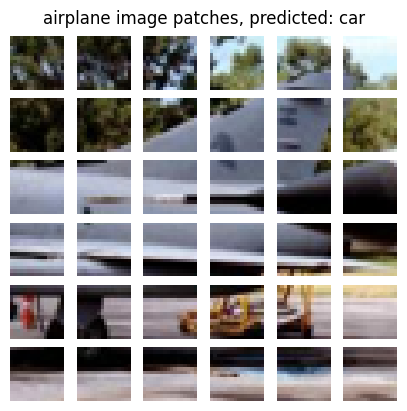

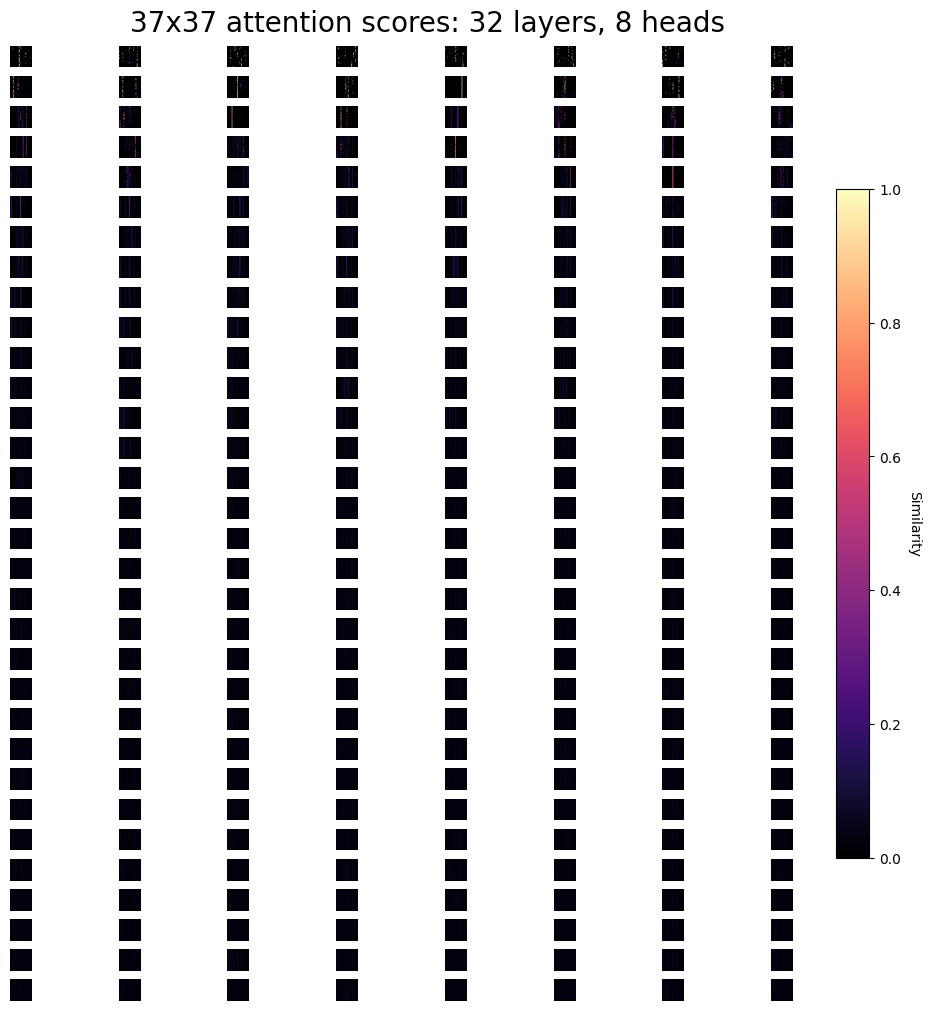

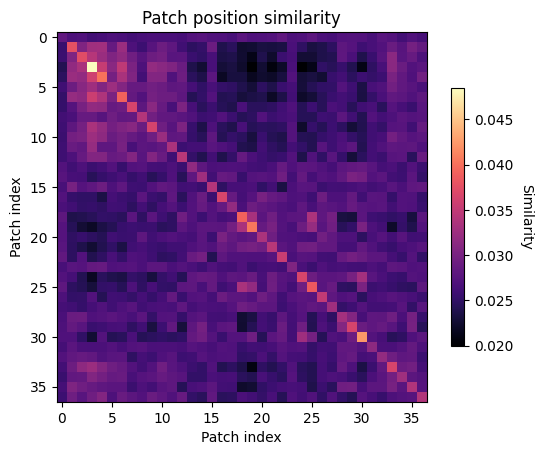

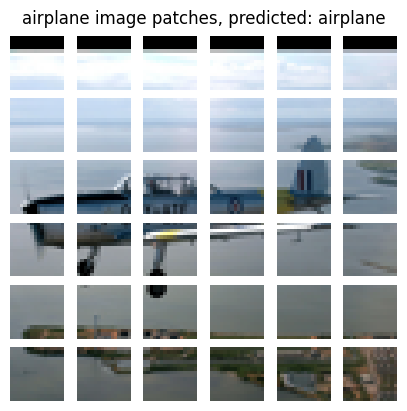

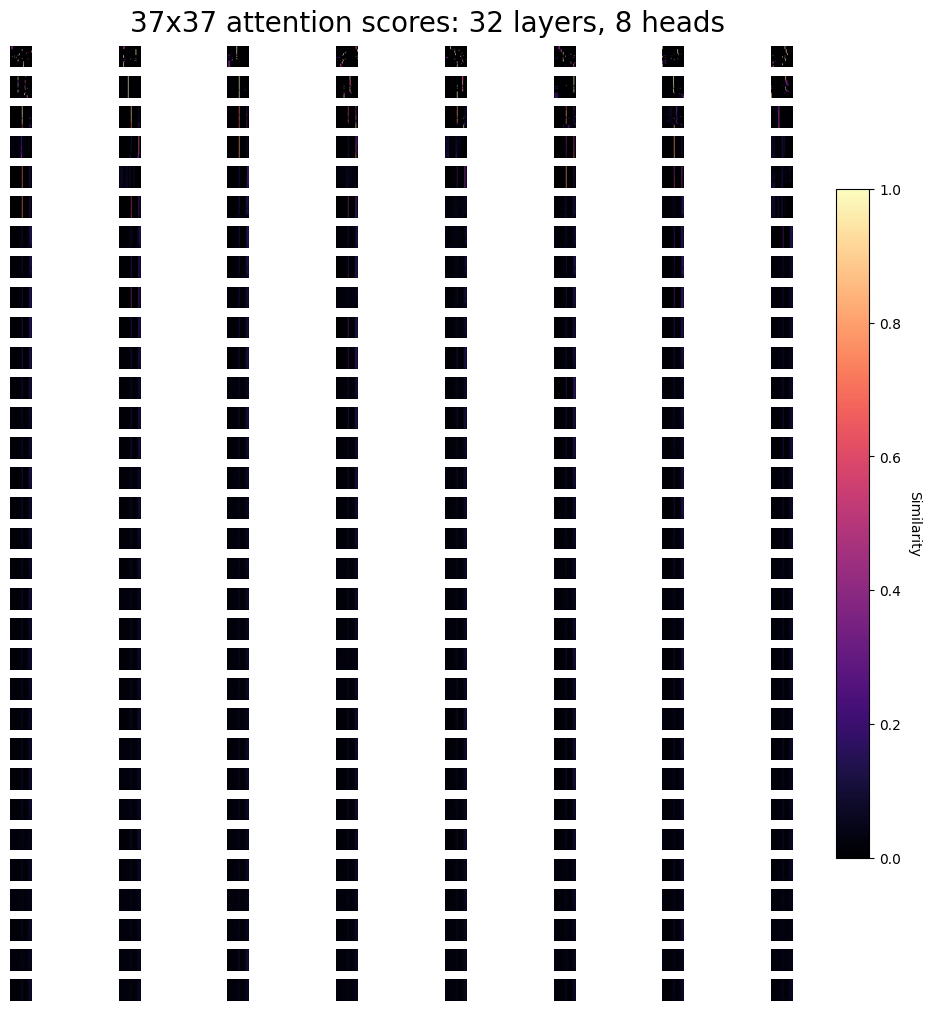

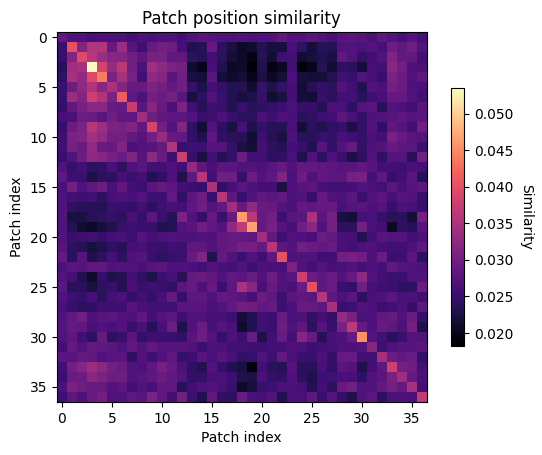

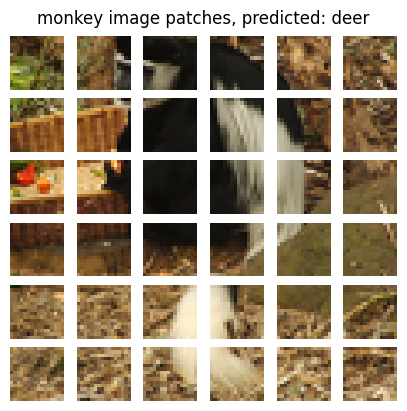

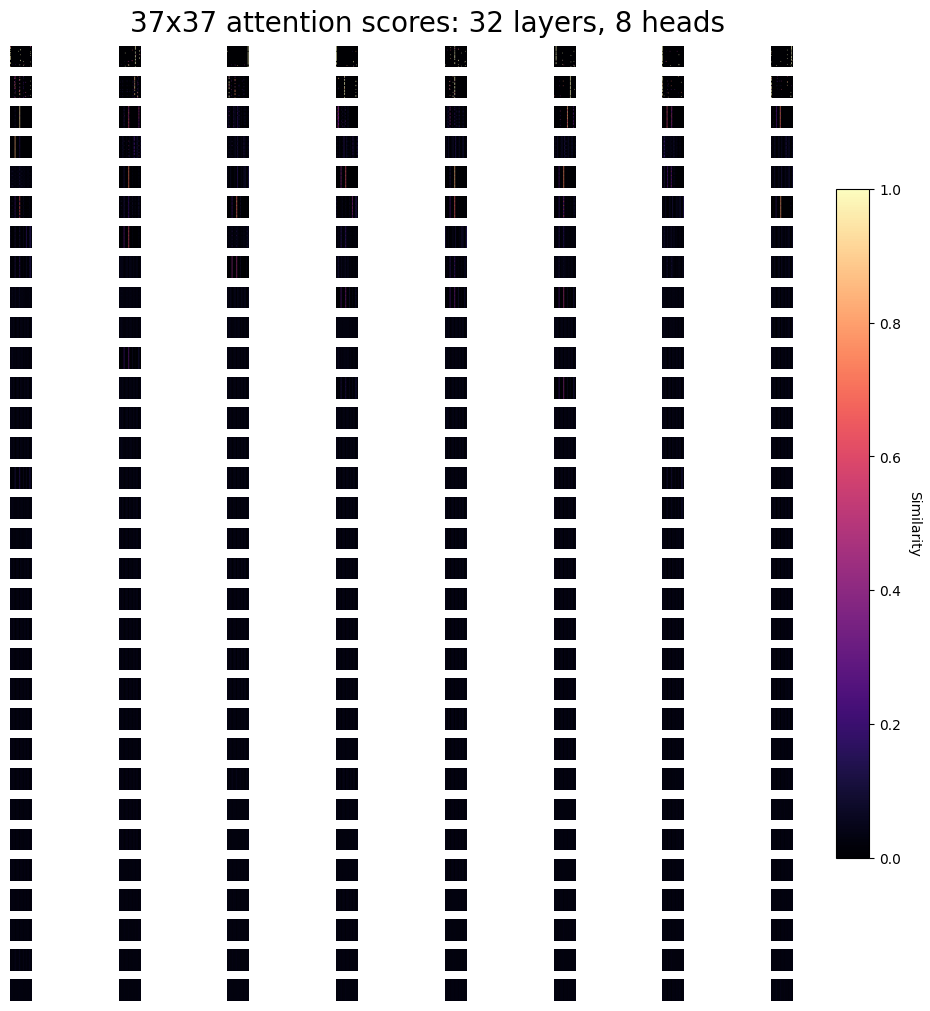

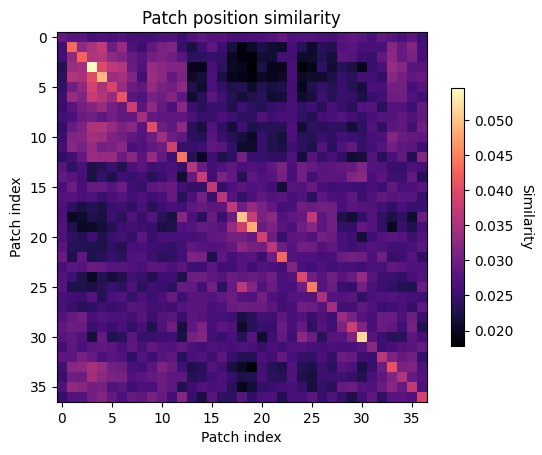

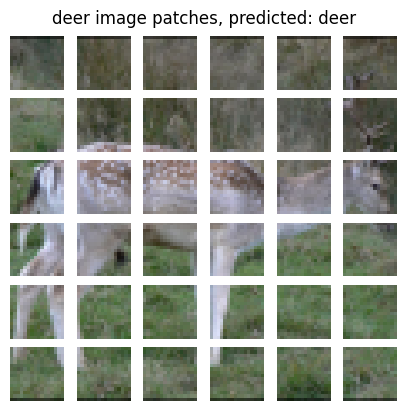

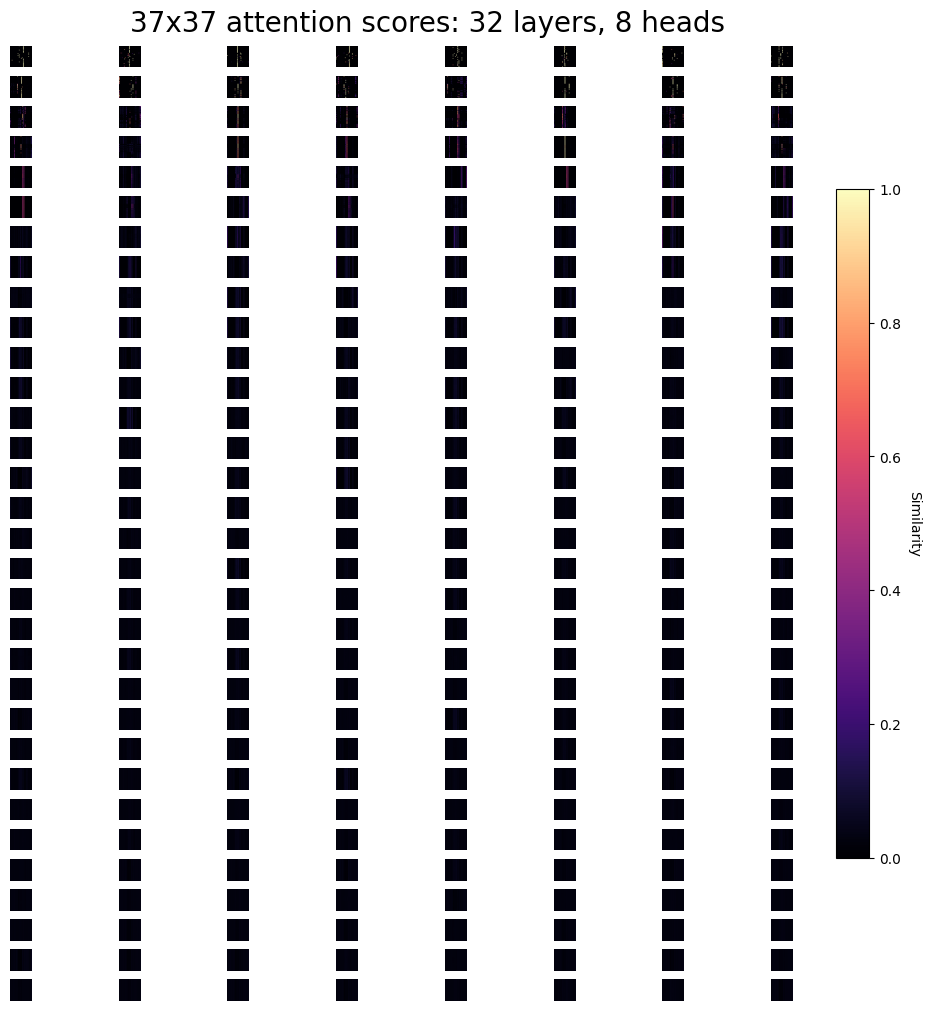

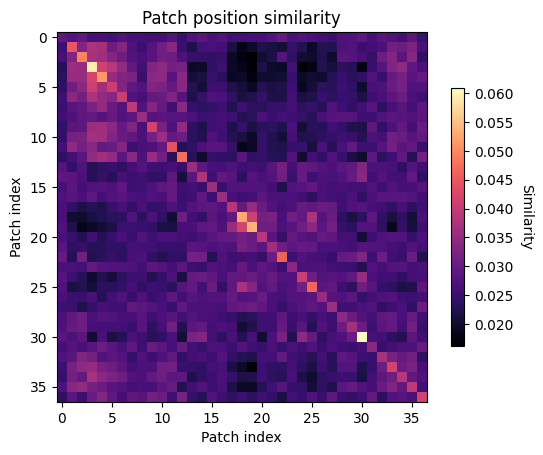

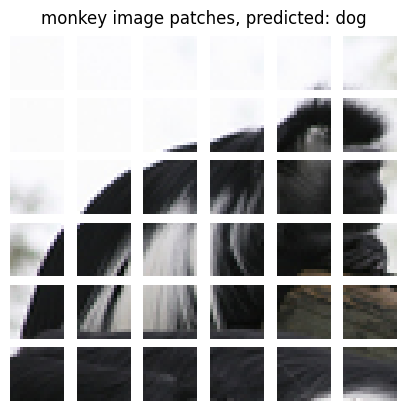

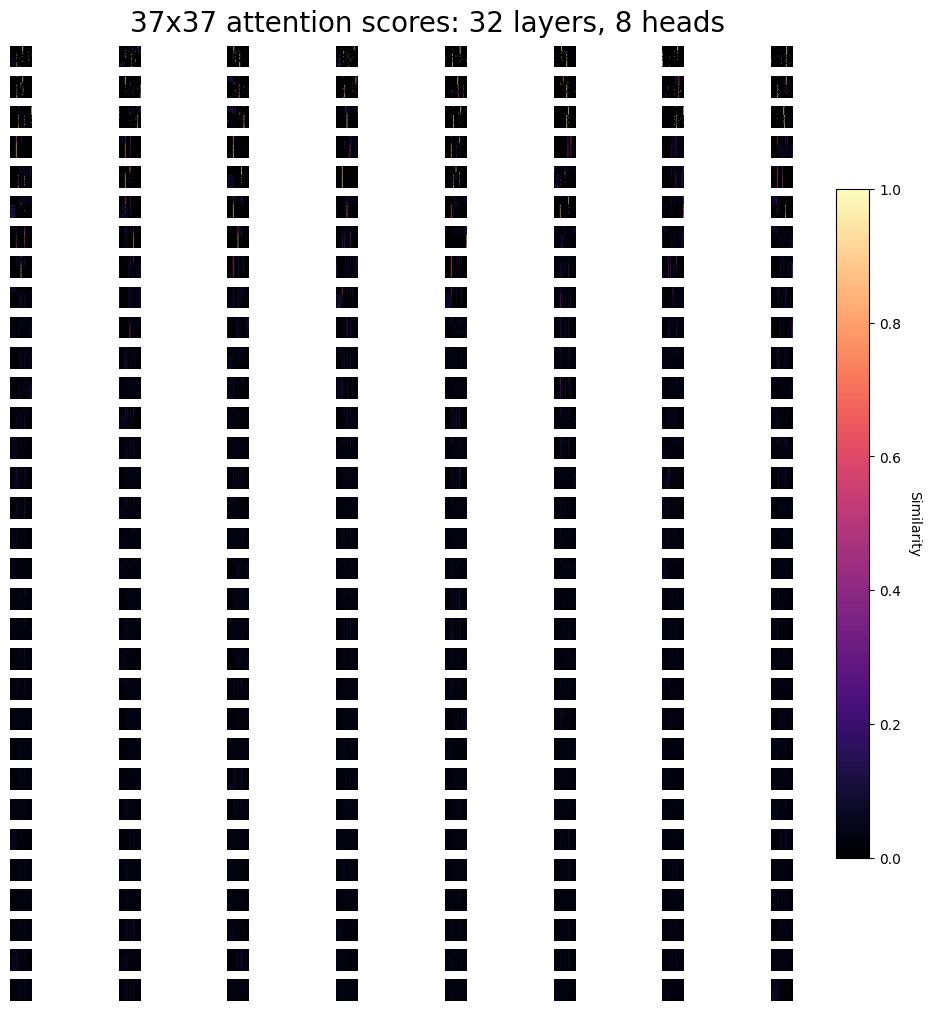

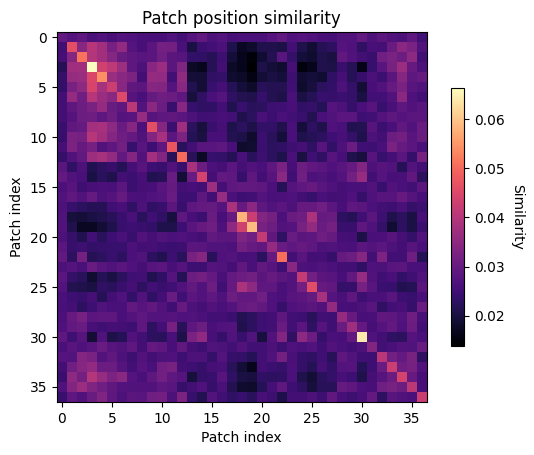

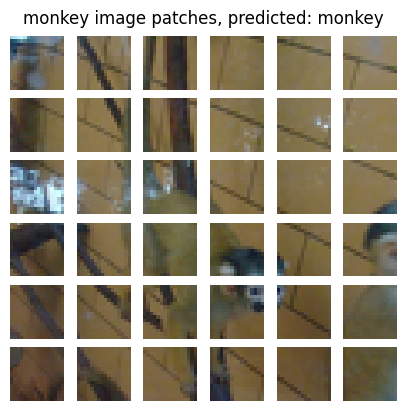

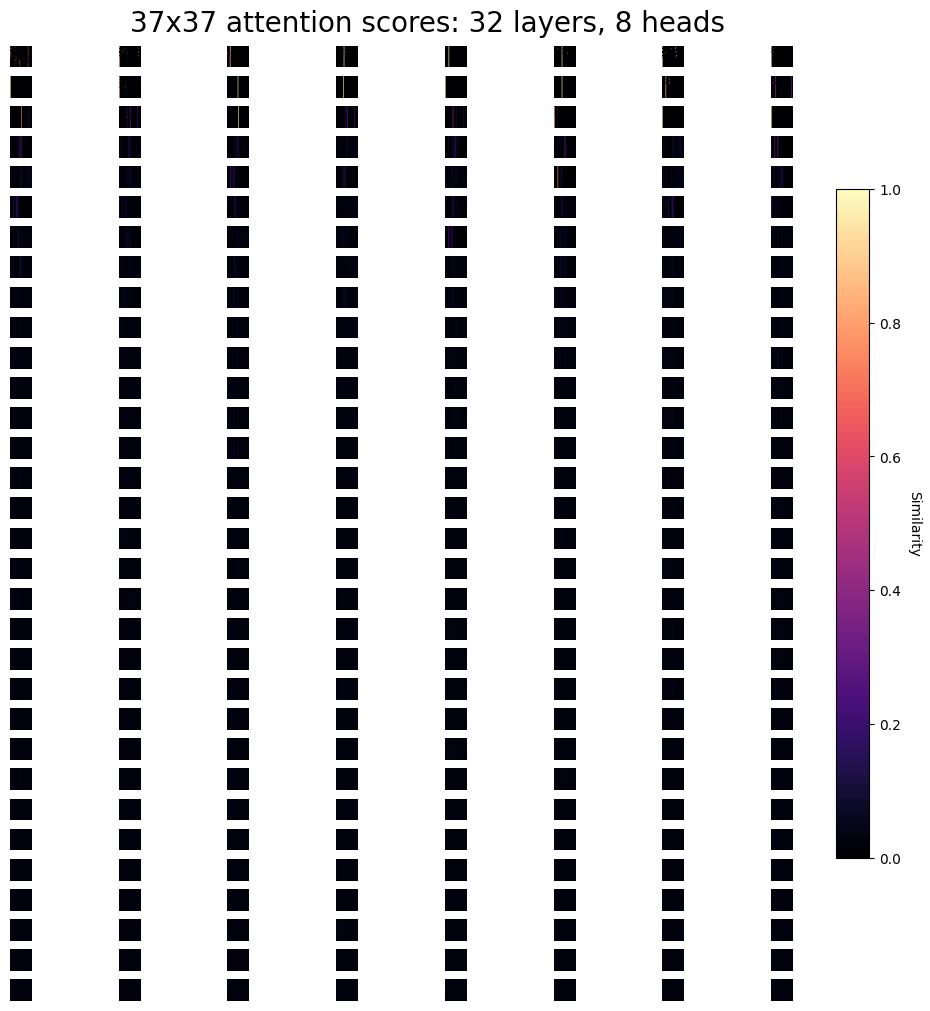

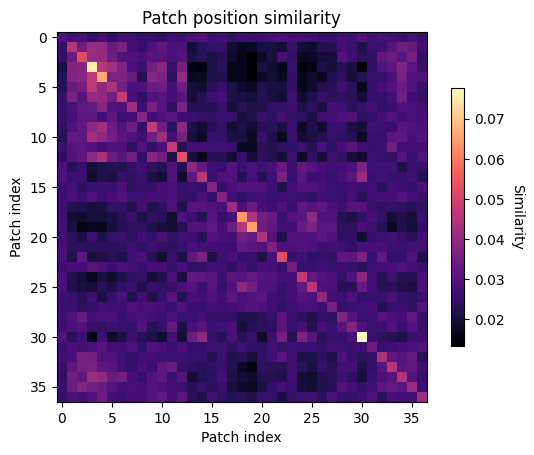

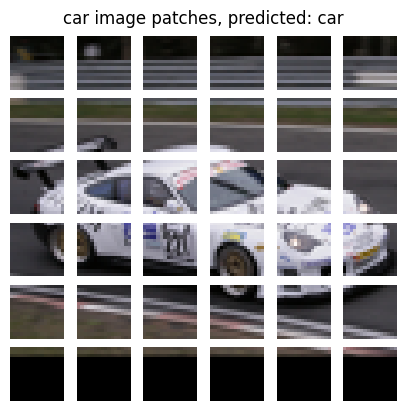

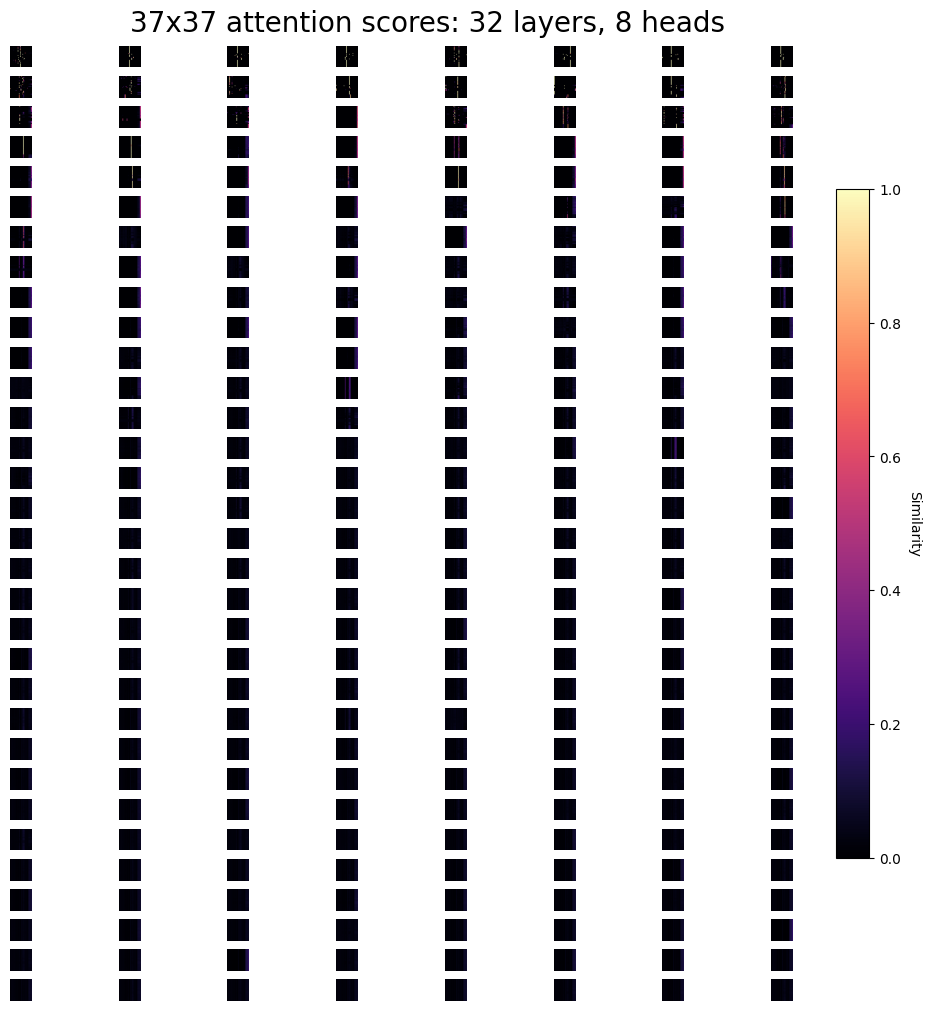

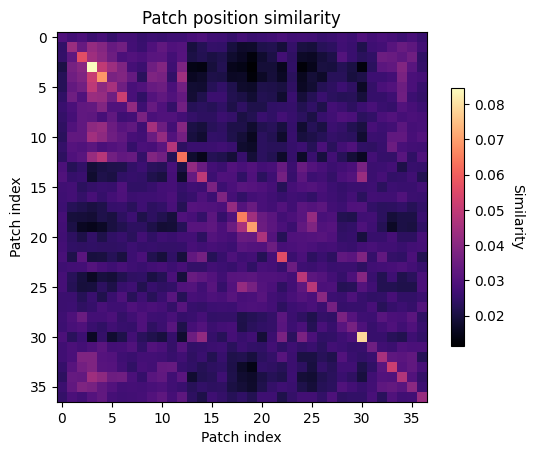

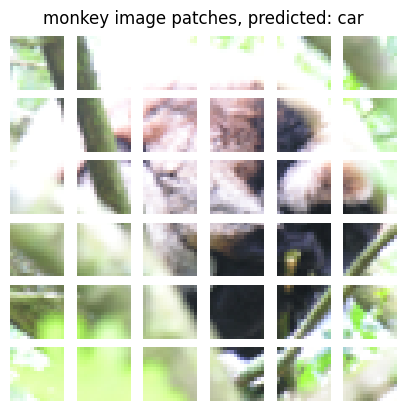

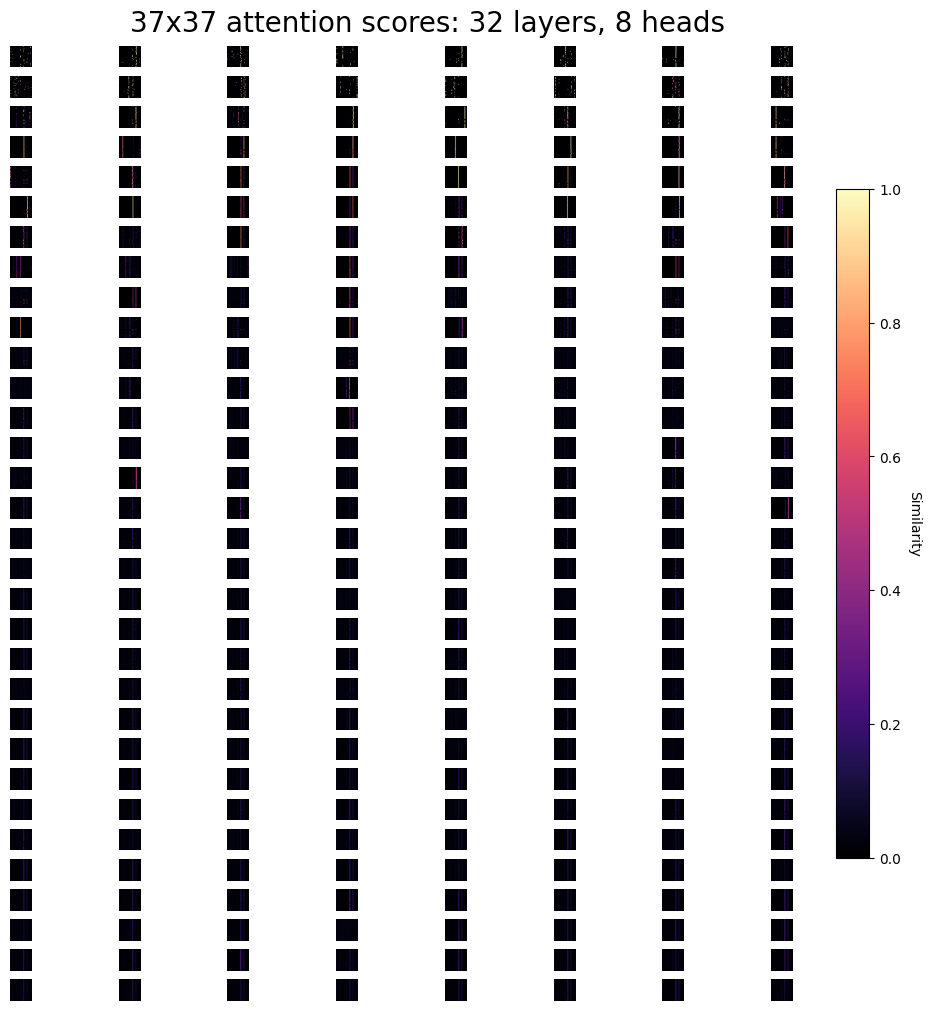

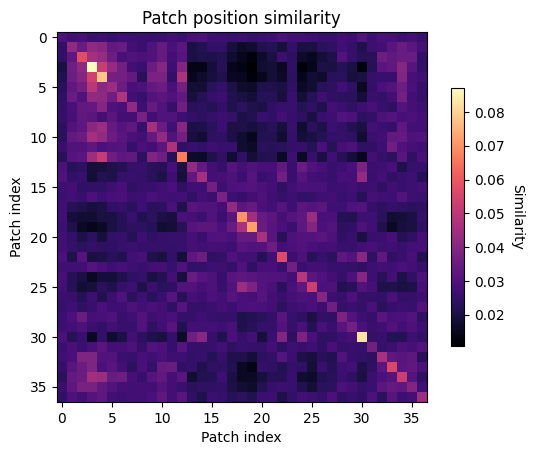

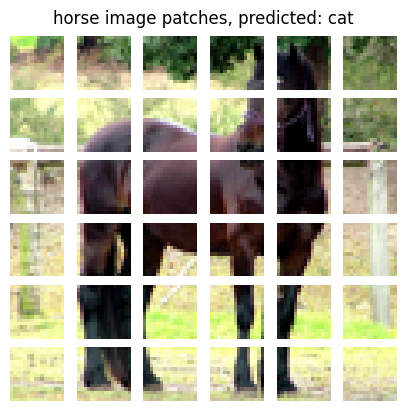

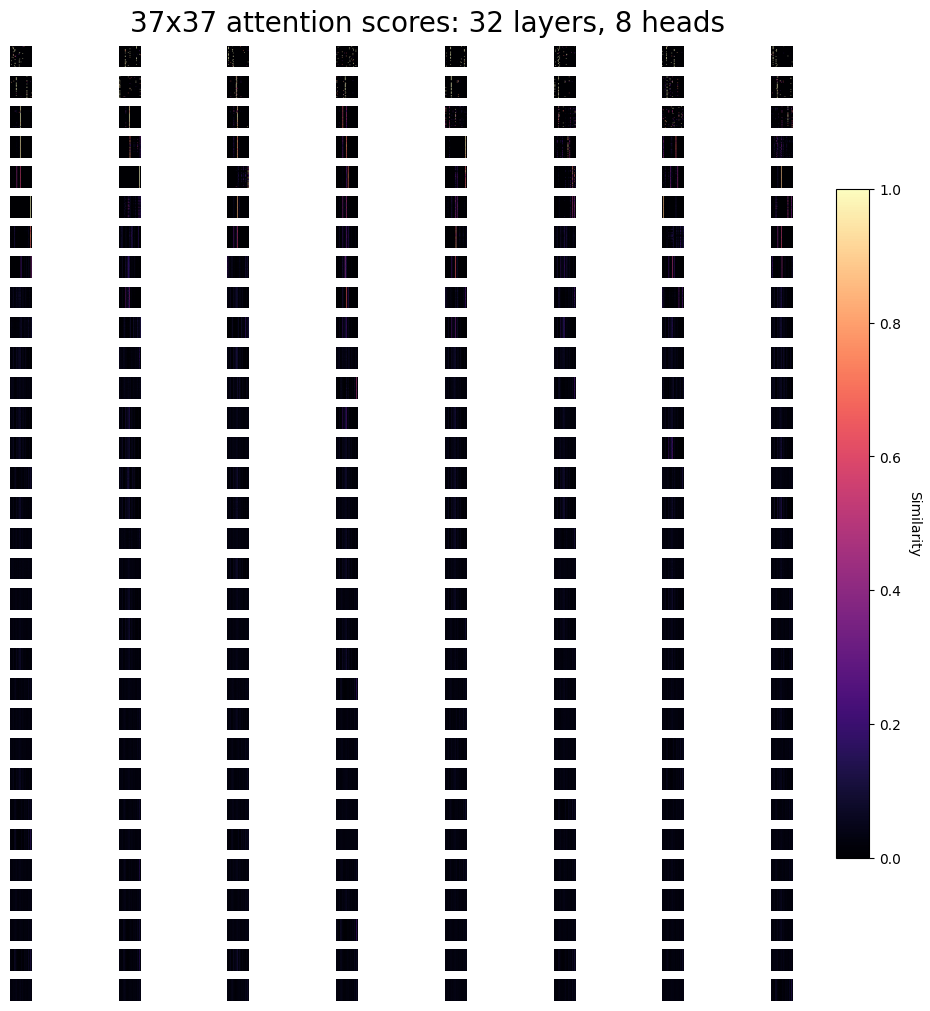

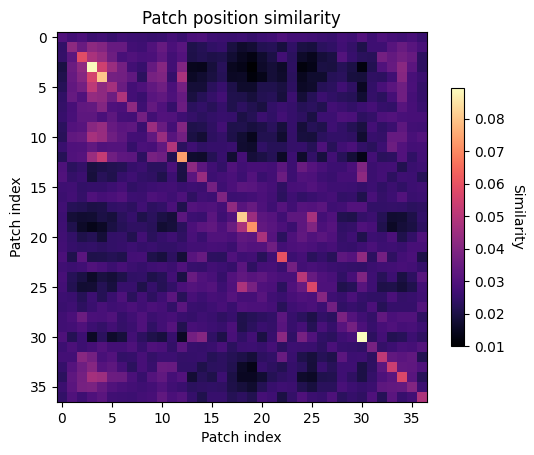

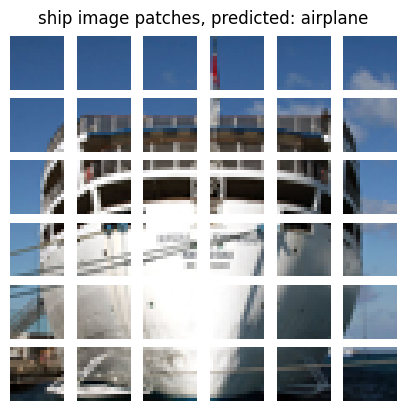

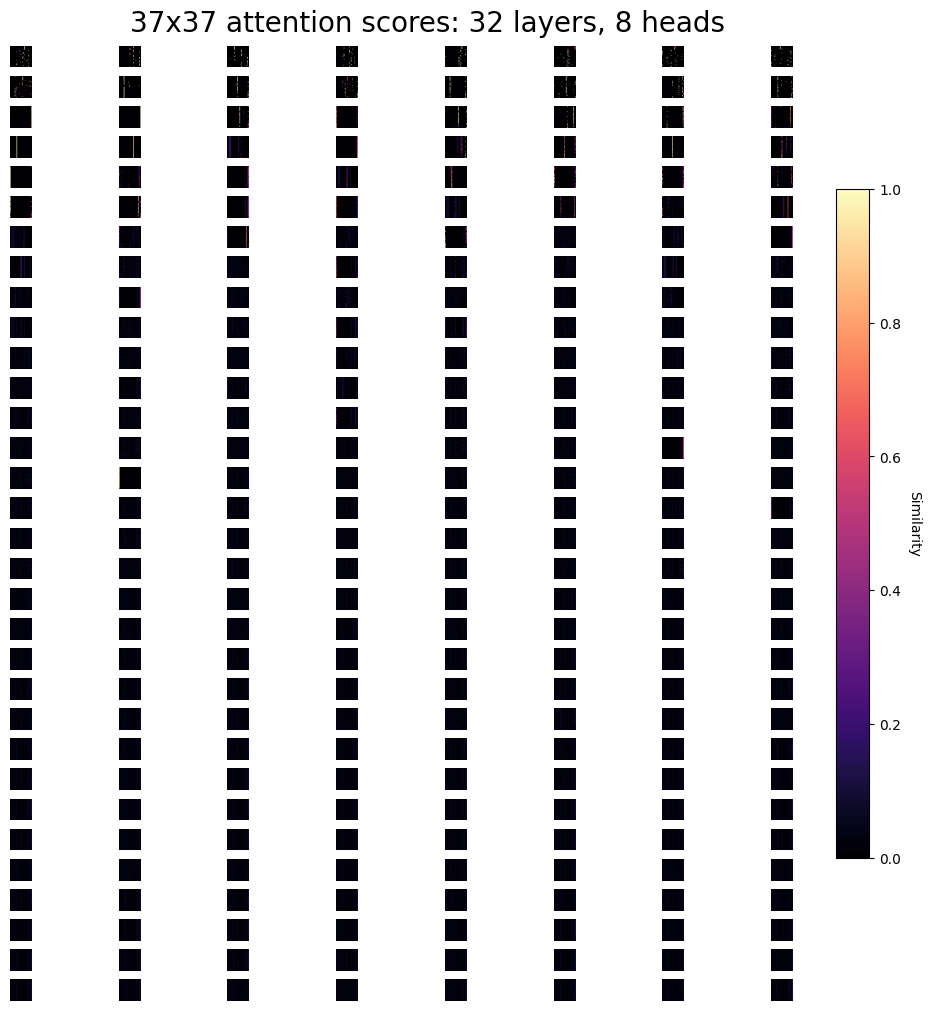

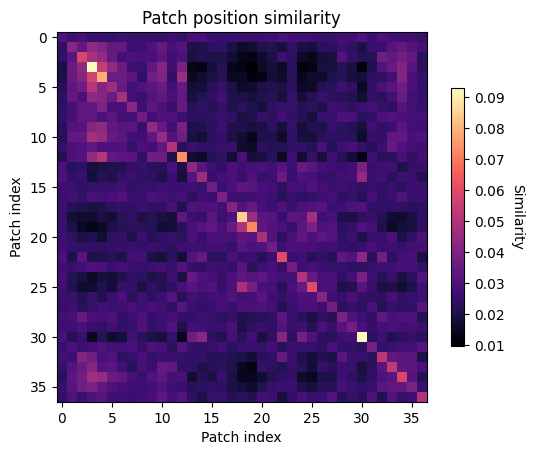

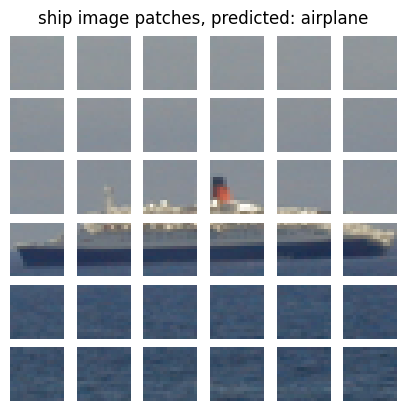

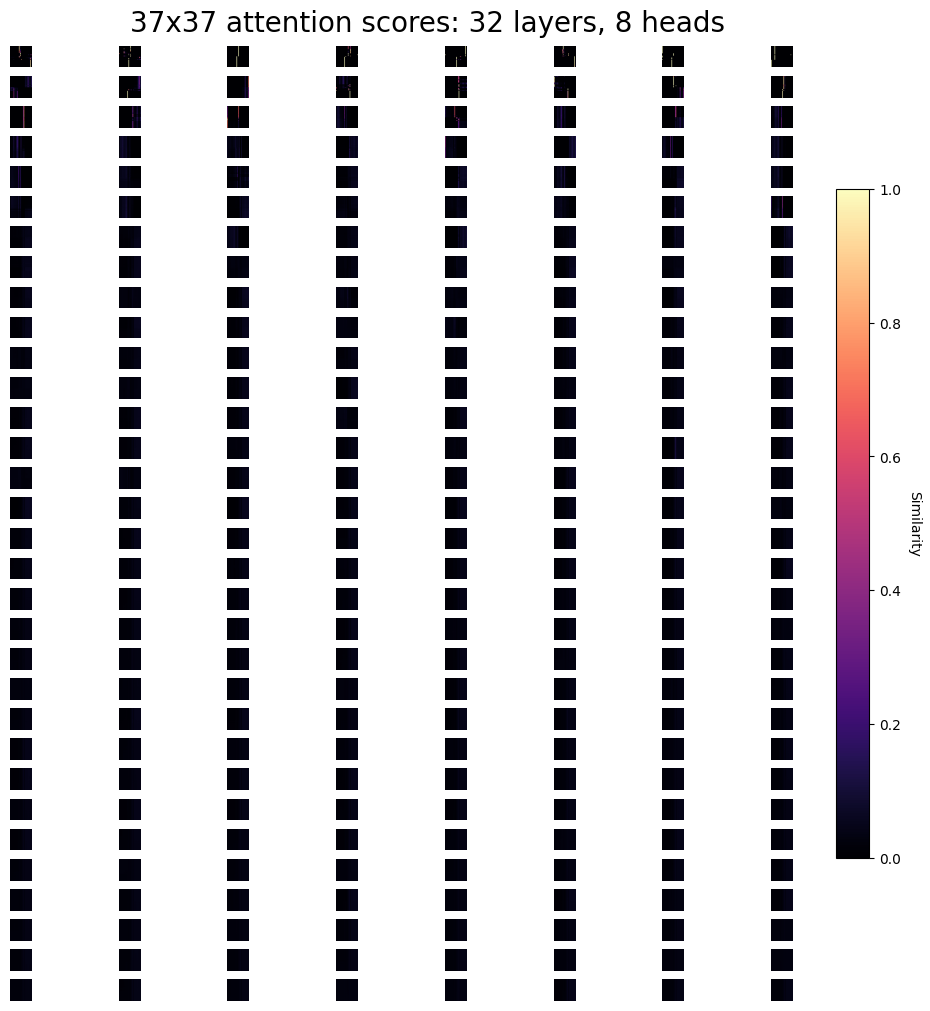

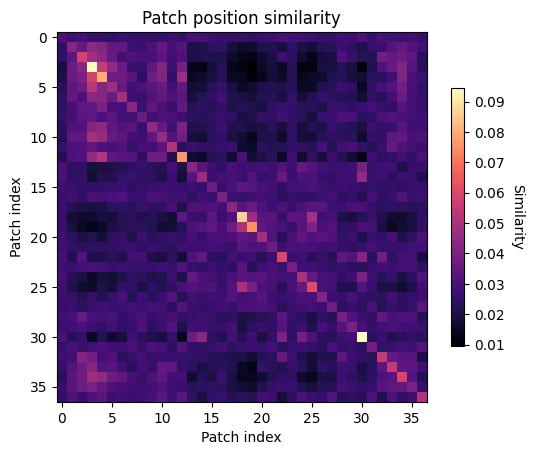

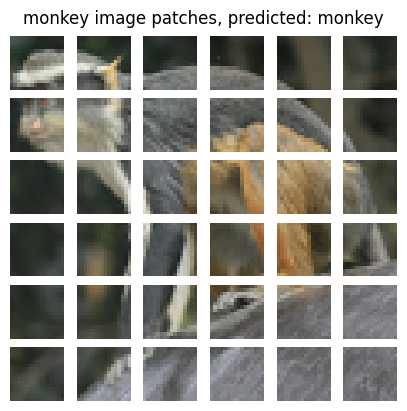

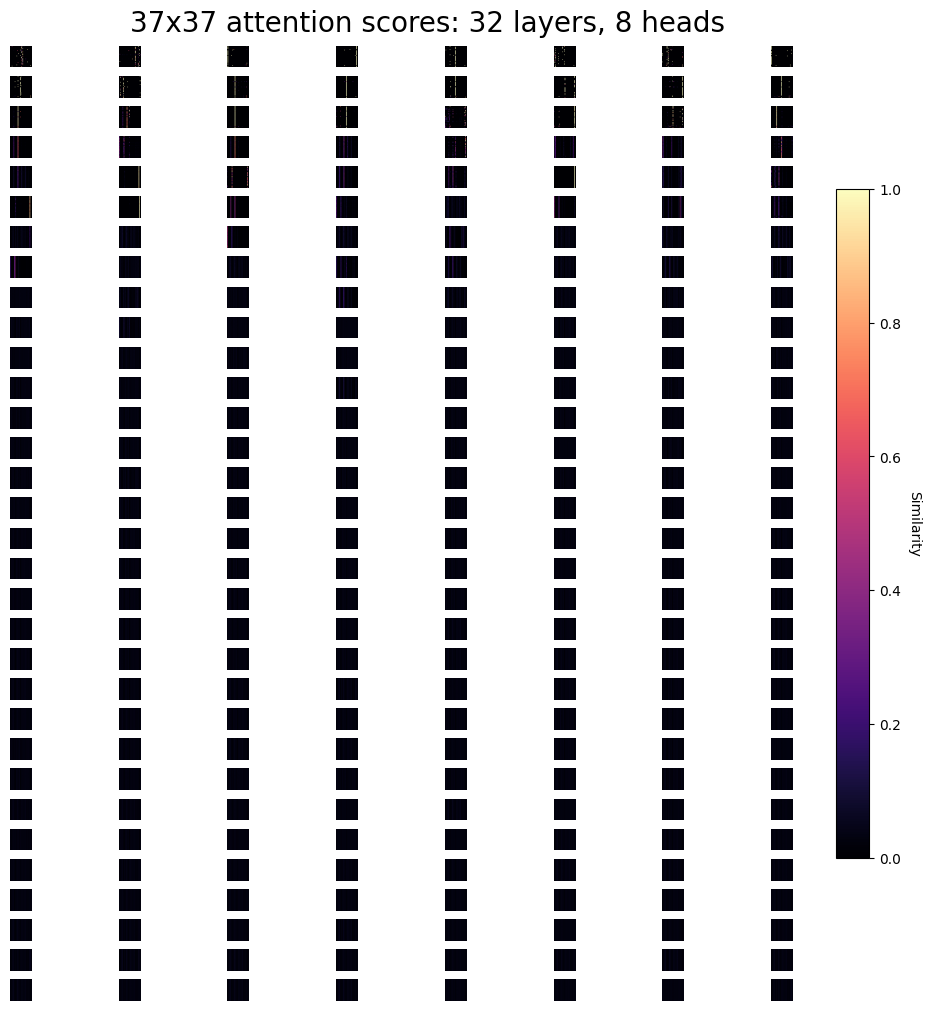

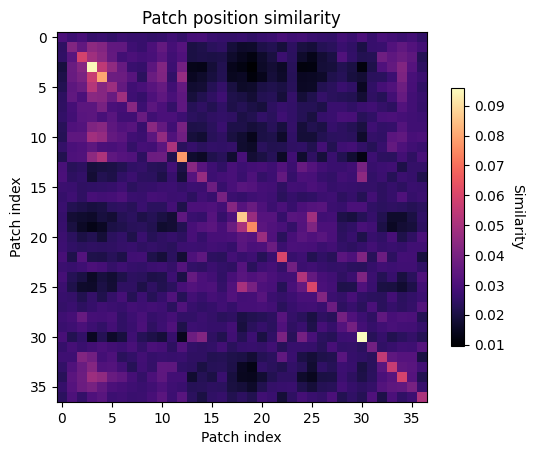

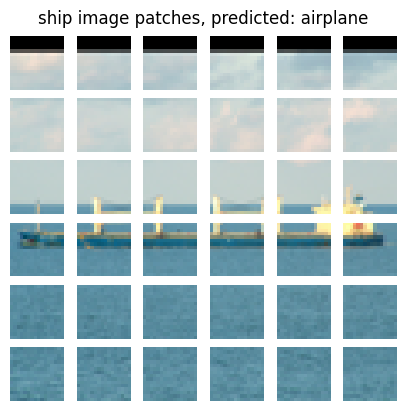

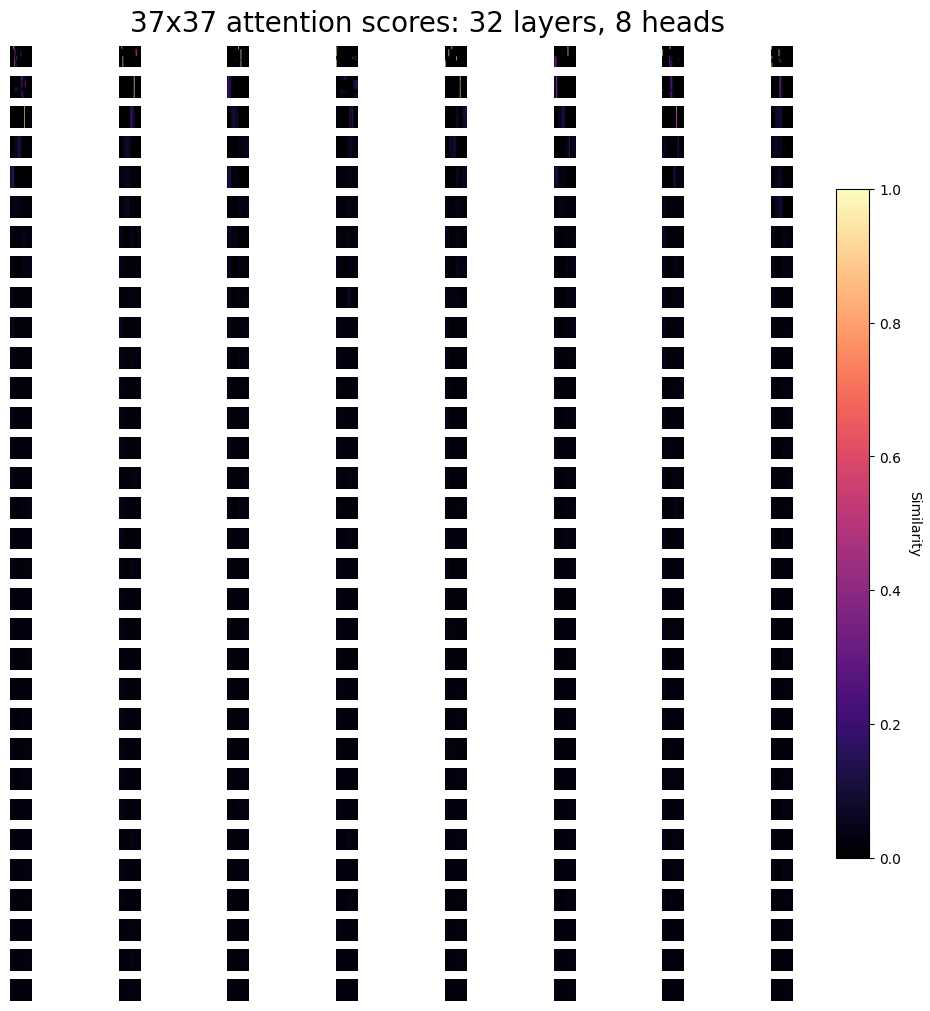

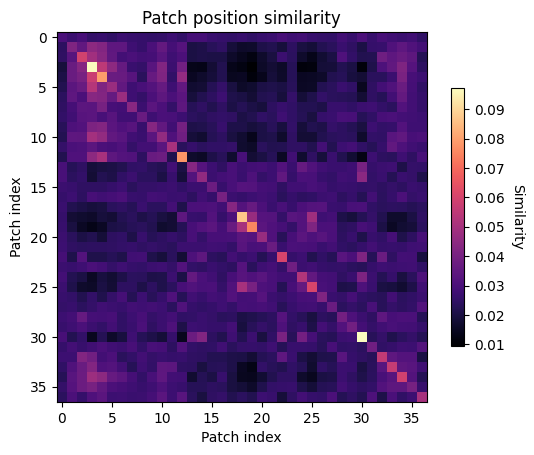

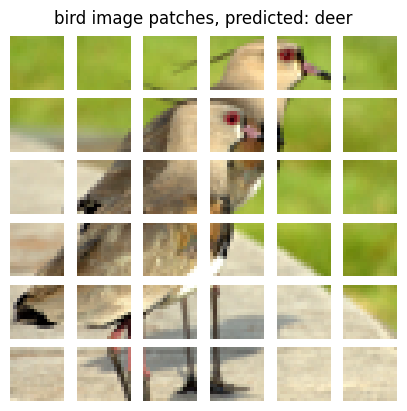

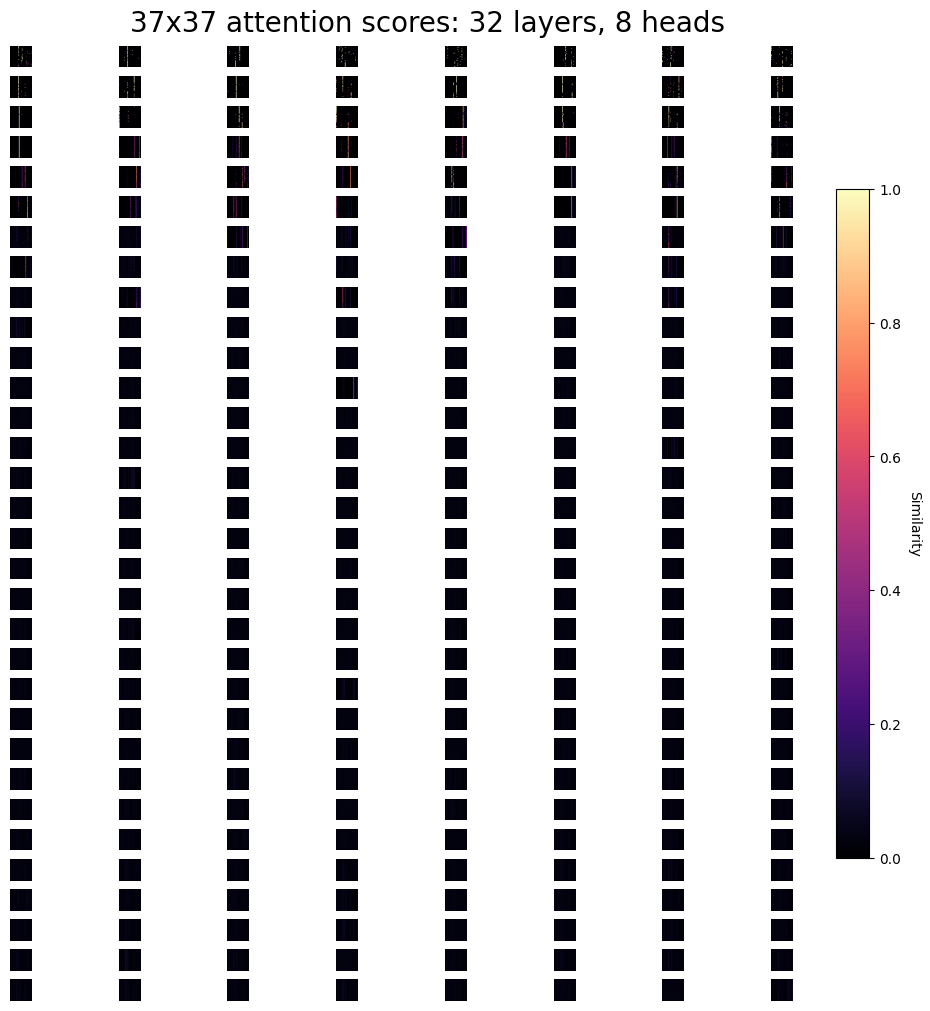

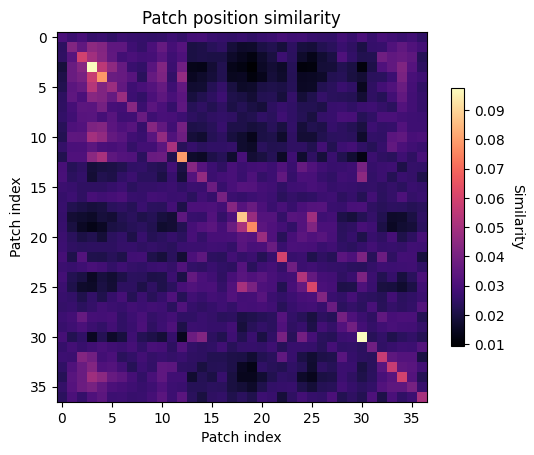

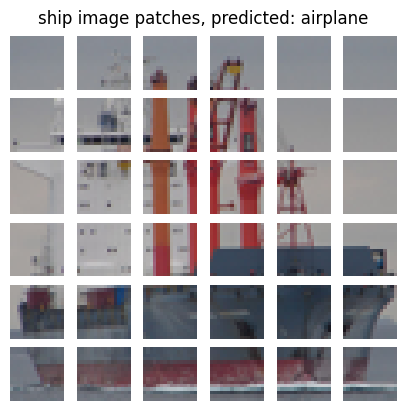

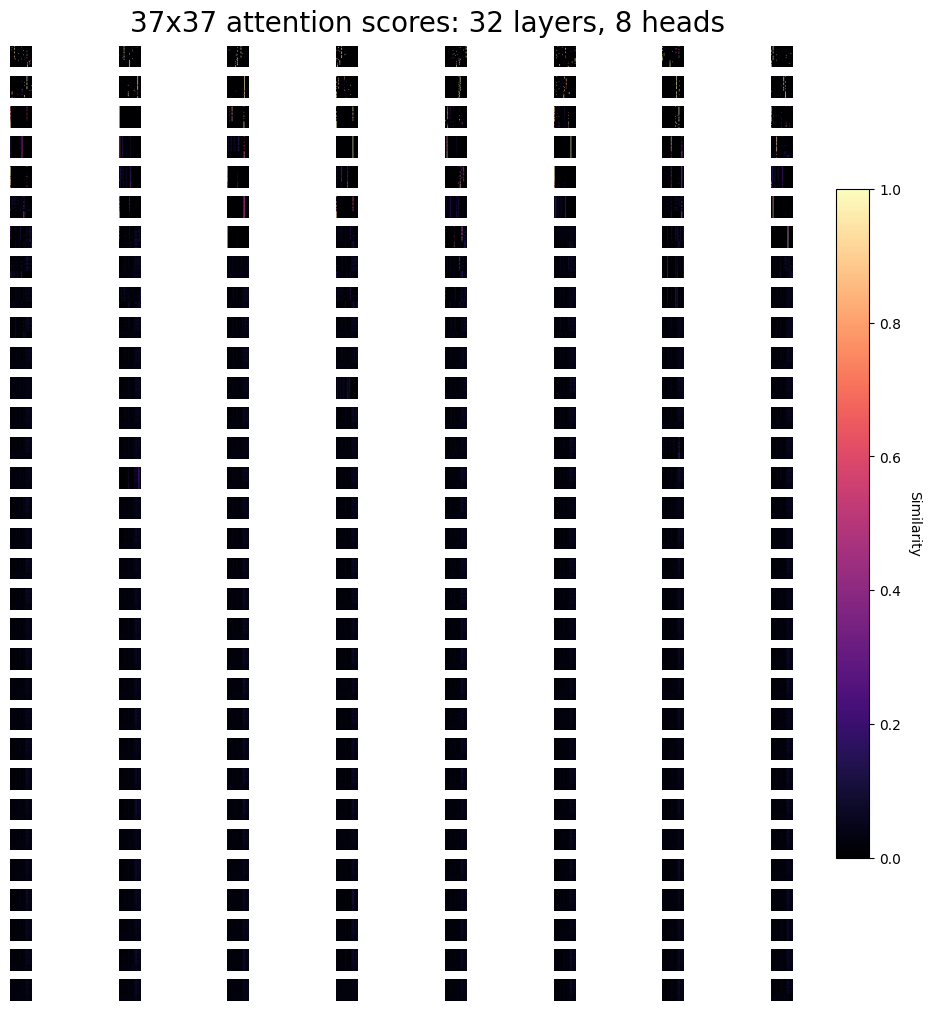

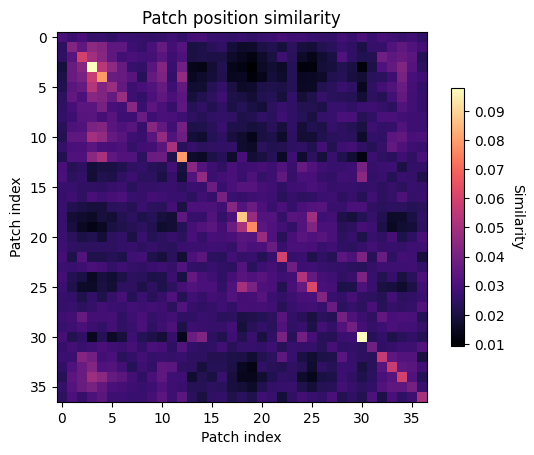

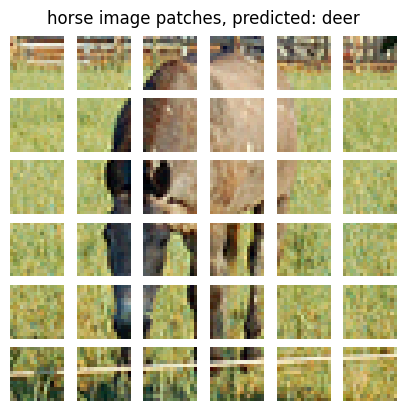

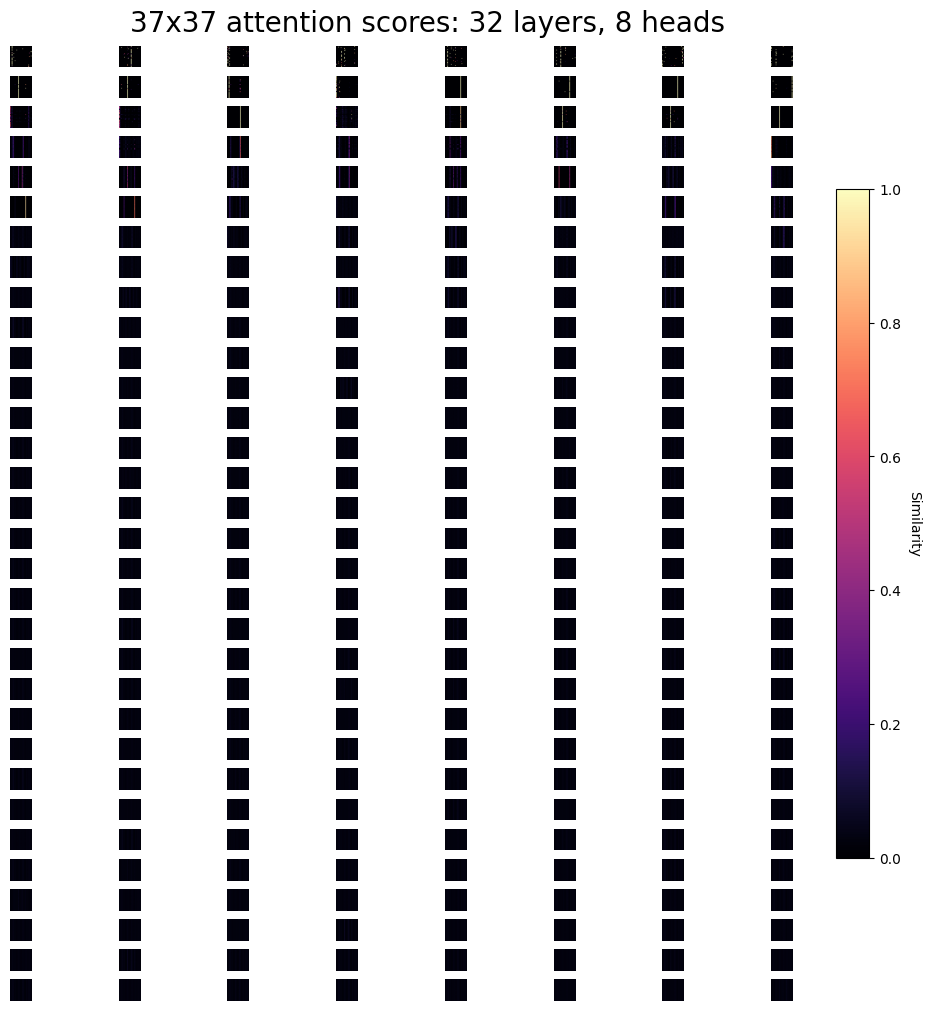

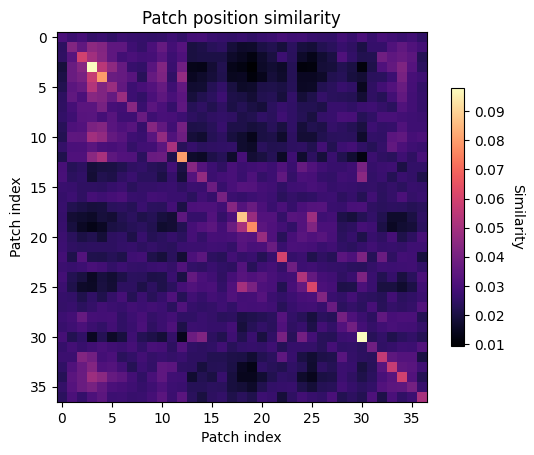

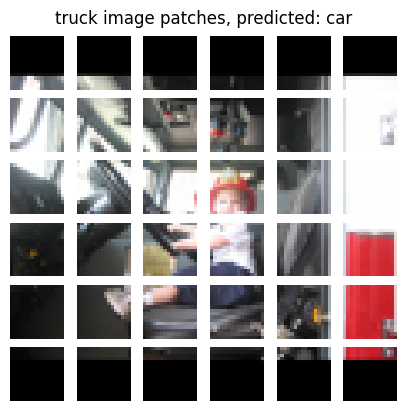

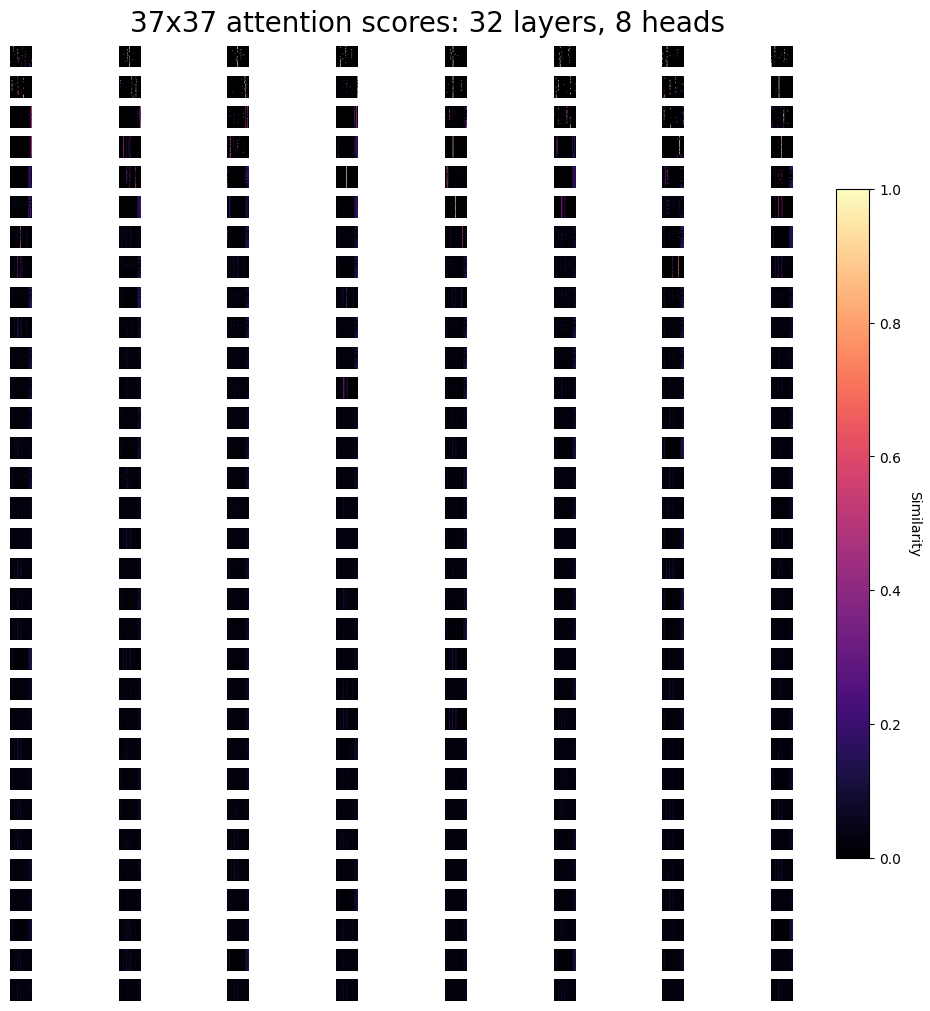

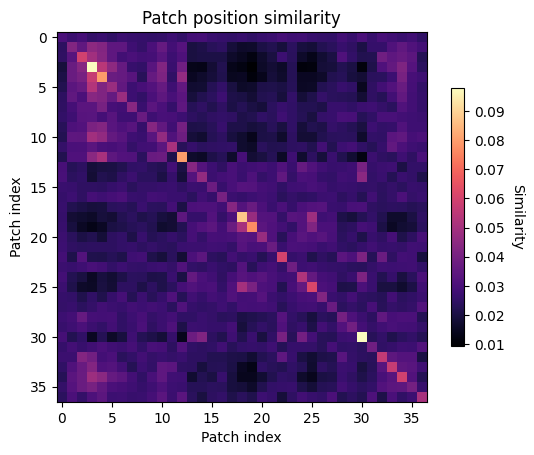

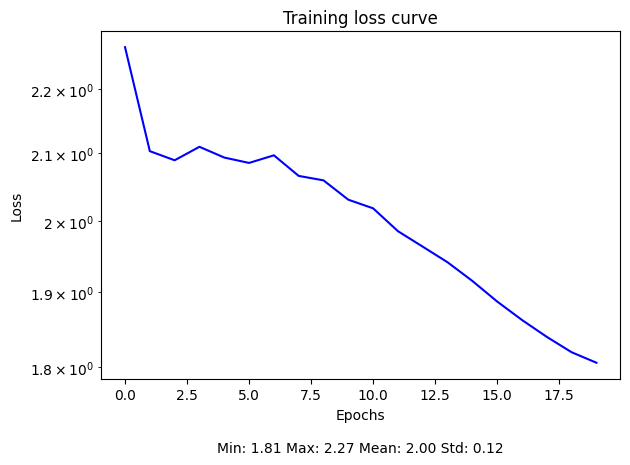

Top 1 Accuracy: 30.20%


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2
import humanize, pathlib

import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def log_training_progress(batch_idx, epoch, total_epochs, loss, bar_length, loader):
  num_batches = len(loader)
  batch_count = epoch * num_batches + batch_idx
  progress = batch_count / (total_epochs * num_batches)
  num_bars = progress * bar_length
  progress_bar = '█' * int(num_bars) + ' ' * int(bar_length - num_bars)
  end = "\n" if num_bars == bar_length else "\r"
  info = f"Batch {batch_idx + 1} / {num_batches} | Epoch {epoch + 1} / {total_epochs}"
  print(f"{info} | [{progress_bar}] | Loss: {loss:.3f} \033[K", end=end, flush=True)

def plot_loss_curve(data, output_path):
  data = torch.tensor(data)
  vmin, vmax = data.min().item(), data.max().item()
  mean, std = data.mean().item(), data.std().item()
  fig, ax = plt.subplots()
  ax.set_title("Training loss curve")
  ax.set_xlabel("Epochs")
  ax.set_ylabel("Loss")
  ax.plot(data, "b-")
  ax.text(0.5, -0.18, f"Min: {vmin:.2f} Max: {vmax:.2f} Mean: {mean:.2f} Std: {std:.2f}",
          transform=ax.transAxes, ha="center", va="top", fontsize=10)
  ax.set_yscale("log")
  ax.yaxis.set_major_formatter(ScalarFormatter())
  fig.tight_layout()
  fig.savefig(output_path, bbox_inches="tight")
  plt.show()

def viz_patches(patches, patch_shape, fig_grid,
                      true_label, predicted_label, fig_path):
  N, Px, Py, C = patch_shape
  reshaped = patches.reshape(N, Px, Py, C)

  fig, axs = plt.subplots(nrows=fig_grid[0], ncols=fig_grid[1],
                            figsize=(4, 4), layout="constrained")
  axs = axs.flatten()
  fig.suptitle(f"{true_label} image patches, predicted: {predicted_label}")

  for i in range(N):
    img = (reshaped[i] + 1) / 2
    axs[i].imshow(img)
    axs[i].axis("off")
  fig.savefig(fig_path)

def viz_attn_scores(layer_scores, fig_grid, fig_path):
  fig, axs = plt.subplots(nrows=fig_grid[0], ncols=fig_grid[1],
                          figsize=(10, 10), layout="constrained")
  axs = axs.flatten()

  vmin, vmax = layer_scores.min().item(), layer_scores.max().item()
  layers, heads, N = layer_scores.shape[0:3]
  fig.suptitle(f"{N}x{N} attention scores: {layers} layers, {heads} heads", fontsize=20)

  for l in range(layers):
    for h in range(heads):
      idx = l * heads + h
      image = axs[idx].imshow(layer_scores[l, h], vmin=vmin, vmax=vmax, cmap="magma")
      axs[idx].axis("off")

  cbar = fig.colorbar(image, ax=axs, location="right", shrink=0.7)
  cbar.ax.set_ylabel("Similarity", va="bottom", rotation=-90)
  fig.savefig(fig_path)

def viz_pos_embeds(pos_embed, fig_path):
  fig, ax1 = plt.subplots()
  ax1.set_title("Patch position similarity")
  ax1.set_xlabel("Patch index")
  ax1.set_ylabel("Patch index")

  logits = pos_embed @ pos_embed.T
  similarity = torch.nn.functional.softmax(logits, dim=-1)
  heatmap = ax1.imshow(similarity, cmap="magma")

  cbar = fig.colorbar(heatmap, ax=ax1, location="right", shrink=0.7)
  cbar.ax.set_ylabel("Similarity", va="bottom", rotation=-90)
  fig.savefig(fig_path)

def viz_model_features(prediction, patches, labels, scores, pos_embeds,
                       h, score_fig_path, patch_fig_path, pos_fig_path):
  G = h.img_size // h.patch_size
  patch_shape = [G * G, h.patch_size, h.patch_size, 3]

  i = torch.randint(patches.shape[0], size=(1, )).item()
  label_idx = labels[i].item()
  max_idx = prediction[i].argmax(dim=-1).item()

  label = h.classes[label_idx]
  predicted_label = h.classes[max_idx]

  p = patches[i].cpu().detach().numpy()
  s = scores[:, i].cpu().detach().numpy()

  viz_patches(p, patch_shape, [G, G], label, predicted_label, patch_fig_path)
  viz_attn_scores(s, [h.layers, h.attn_heads], score_fig_path)
  viz_pos_embeds(pos_embeds, pos_fig_path)

class Hyperparams:
  def __init__(self):
    self.epochs = 20
    self.batch_size = 64
    self.learning_rate = 1e-3
    self.betas = [0.9, 0.999]
    self.label_smoothing = 0.1
    self.img_size = 96
    self.embedding_dim = 512
    self.patch_size = 16
    self.attn_heads = 8
    self.layers = 32
    self.class_dim = 128
    self.classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

def patchify_img(img_batch, B, C, P, G):
  # Convert image into a sequence of patches
  patches = img_batch.unfold(2, P, P).unfold(3, P, P)
  patches = patches.contiguous().view(B, C, G * G, P, P)
  patches = patches.permute(0, 2, 3, 4, 1)
  patches = patches.flatten(start_dim=2, end_dim=4)
  return patches

def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    if module.bias is not None:
      nn.init.zeros_(module.bias)

class MSA(nn.Module):
  def __init__(self, attn_heads, embed_dim):
    super().__init__()
    self.Q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.K_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.V_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.O_proj = nn.Linear(embed_dim, embed_dim, bias=False)
    self.attn_softmax = nn.Softmax(dim=-1)
    self.variance_scale = 1 / torch.sqrt(torch.tensor(embed_dim // attn_heads)).item()
    self.H = attn_heads

  # Input and output shape: (B, N + 1, D)
  # D = embedding dimension, H = number of attention heads
  def forward(self, x):
    B, N, D = x.shape
    Q = self.Q_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)
    K = self.K_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)
    V = self.V_proj(x).view((B, N, self.H, D // self.H)).permute(0, 2, 1, 3)

    scores = (Q @ K.permute(0, 1, 3, 2))
    norm = self.attn_softmax(scores * self.variance_scale)

    output = (norm @ V).permute(0, 2, 1, 3).reshape(B, N, D)
    return self.O_proj(output), norm

class ViT(nn.Module):
  def __init__(self, patch_size, grid_size, embed_dim,
               layers, attn_heads, class_dim, num_classes):
    super().__init__()
    size = 3 * patch_size * patch_size
    elements = grid_size * grid_size + 1

    self.embed_filters = nn.Linear(size, embed_dim, bias=False)
    self.class_token = nn.Parameter(torch.zeros(embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(elements, embed_dim))

    self.layers = nn.ModuleList([
      nn.ModuleList([
        nn.LayerNorm(embed_dim),
        MSA(attn_heads, embed_dim),
        nn.LayerNorm(embed_dim),
        nn.Sequential(
          nn.Linear(embed_dim, embed_dim * 4),
          nn.GELU(),
          nn.Linear(embed_dim * 4, embed_dim)),
      ])
      for _ in range(layers)
    ])

    self.class_norm = nn.LayerNorm(embed_dim)
    self.class_head = nn.Sequential(
      nn.Linear(embed_dim, class_dim),
      nn.Tanh(),
      nn.Linear(class_dim, num_classes)
    )

  # P = patch size, N = patch count, C = channel count
  # B = batch size, O = number of output classes
  # Input shape: (B, N, P * P * C), output shape: (B, O)
  def forward(self, x):
    layer_scores = []

    embeddings = self.embed_filters(x)
    tok = self.class_token.unsqueeze(0).unsqueeze(0)
    tok = tok.expand(x.shape[0], -1, -1)
    tokens = torch.cat((tok, embeddings), dim=1)
    z = tokens + self.pos_embed

    for layer in self.layers:
      prev_norm, msa, msa_norm, mlp = layer
      z1, scores = msa(prev_norm(z))
      z1 = z1 + z
      z = mlp(msa_norm(z1)) + z1
      layer_scores.append(scores)

    class_token = self.class_norm(z[:, 0])
    prediction = self.class_head(class_token)
    layer_scores = torch.stack(layer_scores, dim=0)
    return prediction, layer_scores

torch.manual_seed(67)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

h, out_folder = Hyperparams(), "trial6"
pathlib.Path(out_folder).mkdir(parents=True, exist_ok=True)

augment_pipeline = v2.Compose([
  v2.RGB(), v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Resize(size=(h.img_size, h.img_size)),
  v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), # [0, 255] -> [-1, 1]
  #v2.RandomHorizontalFlip(),
  #v2.RandomRotation(90),
  #v2.RandomErasing(p=0.3),
])

train_dataset = datasets.STL10(root=".cache/train/stl10", split="train",
                        download=True, transform=augment_pipeline)
train_loader = DataLoader(train_dataset, batch_size=h.batch_size, shuffle=True)

test_dataset = datasets.STL10(root=".cache/train/stl10", split="test",
                        download=True, transform=augment_pipeline)
test_loader = DataLoader(test_dataset, batch_size=h.batch_size, shuffle=True)

model = ViT(
  h.patch_size, h.img_size // h.patch_size,
  h.embedding_dim, h.layers, h.attn_heads,
  h.class_dim, len(h.classes)
).apply(init_weights).to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Training a {humanize.metric(trainable_params)} model using {device}")

optimizer = AdamW(model.parameters(), lr=h.learning_rate, betas=h.betas)
scheduler = CosineAnnealingLR(optimizer, T_max=h.epochs)
criterion = nn.CrossEntropyLoss(label_smoothing=h.label_smoothing)
losses = []

# Training loop
model.train()

with torch.enable_grad():
  for epoch in range(h.epochs):
    batch_losses = torch.zeros((len(train_loader), 1), device=device)

    for batch, (images, labels) in enumerate(train_loader):
      # Images shape: (B, C, H, W), Patches shape: (B, N, P, P, C)
      images, labels = images.to(device), labels.to(device)
      patches = patchify_img(
        images, images.shape[0],
        images.shape[1], h.patch_size,
        h.img_size // h.patch_size
      )

      prediction, scores = model(patches)
      loss = criterion(prediction, labels)

      batch_losses[batch] = loss.item()
      log_training_progress(batch, epoch, h.epochs, loss.item(), 50, train_loader)

      loss.backward()
      optimizer.step()
      optimizer.zero_grad(set_to_none=False)

      # Visualize the change in attention scores as training progresses
      last_batch = epoch > 0 and batch == len(train_loader) - 1
      first_batch = epoch == 0 and batch == 0
      if first_batch or last_batch:
        pos_embeds = model.pos_embed.cpu().detach()
        viz_model_features(prediction, patches, labels, scores, pos_embeds, h,
                           f"{out_folder}/scores_{epoch + 1}.png",
                           f"{out_folder}/patches_{epoch + 1}.png",
                           f"{out_folder}/pos_similarity_{epoch + 1}.png")

    losses.append(batch_losses.mean().item())
    scheduler.step()

plot_loss_curve(losses, f"{out_folder}/loss.png")
torch.save(model.state_dict(), f"{out_folder}/weights.pth")

# Compute model accuracy
model.eval()
num_correct = 0

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    patches = patchify_img(
      images, images.shape[0],
      images.shape[1], h.patch_size,
      h.img_size // h.patch_size
    )
    prediction, _ = model(patches)

    predicted_labels = prediction.argmax(dim=-1)
    num_correct += (predicted_labels == labels).sum().item()

  accuracy = 100.0 * num_correct / len(test_loader.dataset)
  print(f"Top 1 Accuracy: {accuracy:.2f}%")